In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
import matplotlib.pyplot as plt
import numpy as np
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorWithPadding
)
import evaluate
import torch
print(torch.__version__)
print(torch.cuda.get_arch_list())
print(torch.version.cuda)
import joblib

nps_categories = [
    "KPI_CURRENT_VALUE",
    "KPI_HISTORICAL_COMPARISON",
    "BENCHMARK_COMPARISON",
    "CUSTOMER_CASE_EVIDENCE",
    "METHODOLOGY_DEFINITION",
    "MGMT_COMPENSATION_GOVERNANCE",
    "QUALITATIVE_ONLY",
    "TARGET_OUTLOOK",
    "NPS_SERVICE_PROVIDER",
    "OTHER"
]

2.10.0+cu128
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
12.8


In [26]:
from typing import List
import os

dataframes : List[pd.DataFrame] = []
for file in os.listdir(r"labeled_data\raw"):
    if file.endswith(".xlsx"):
        df = pd.read_excel(os.path.join(r"labeled_data\raw", file), sheet_name="Sheet1", engine="openpyxl")
        dataframes.append(df)

merged_data = pd.concat(dataframes, ignore_index=True)

merged_data.to_csv(r"labeled_data\preprocessed\final_data.csv", index=False)

In [27]:
# Make splits for every nps_category
final_data = pd.read_csv(r"labeled_data\preprocessed\final_data.csv")
for category in nps_categories:
    category_data = final_data[[category, "snippet_text_short"]]
    category_data = category_data.rename(columns={category: "label", "snippet_text_short": "text"})
    category_data.to_csv(rf"labeled_data\preprocessed\nps_category\{category}.csv", index=False)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Category: BENCHMARK_COMPARISON
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       125
           1       1.00      0.88      0.93        24

    accuracy                           0.98       149
   macro avg       0.99      0.94      0.96       149
weighted avg       0.98      0.98      0.98       149



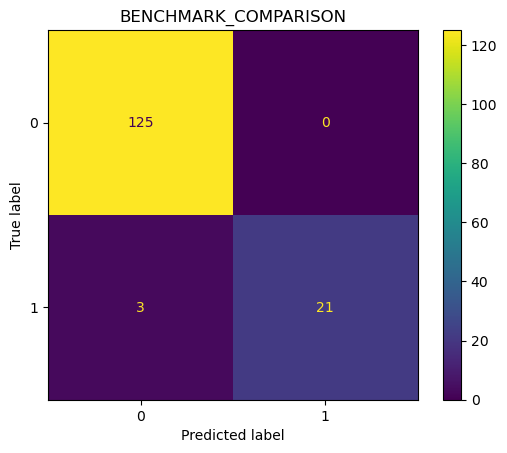

Category: CUSTOMER_CASE_EVIDENCE
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       144
           1       0.75      0.60      0.67         5

    accuracy                           0.98       149
   macro avg       0.87      0.80      0.83       149
weighted avg       0.98      0.98      0.98       149



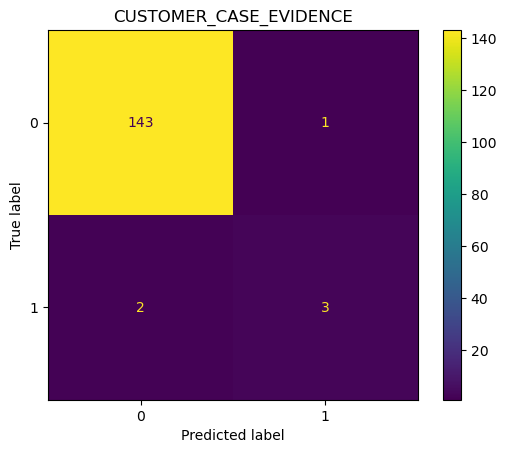

Category: KPI_CURRENT_VALUE
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       136
           1       1.00      0.77      0.87        13

    accuracy                           0.98       149
   macro avg       0.99      0.88      0.93       149
weighted avg       0.98      0.98      0.98       149



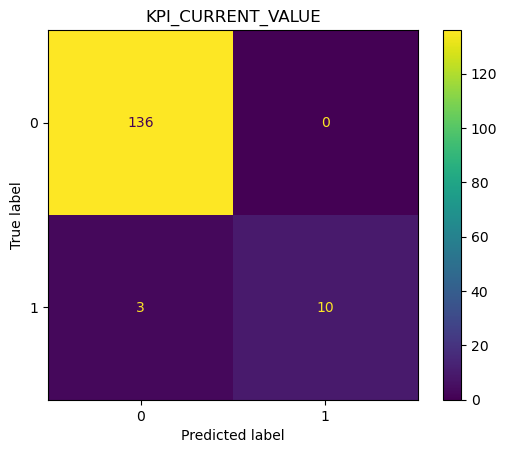

Category: KPI_HISTORICAL_COMPARISON
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       124
           1       0.95      0.72      0.82        25

    accuracy                           0.95       149
   macro avg       0.95      0.86      0.89       149
weighted avg       0.95      0.95      0.94       149



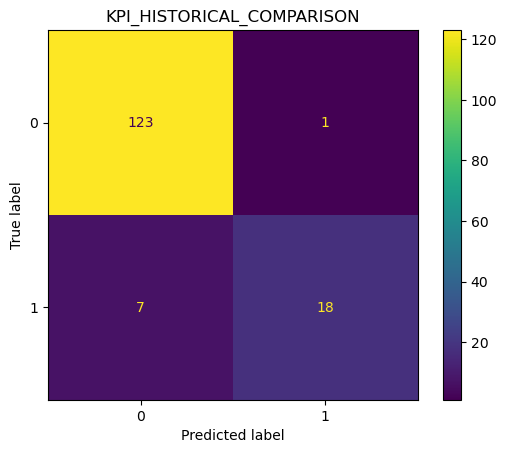

Category: METHODOLOGY_DEFINITION
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       121
           1       0.93      0.89      0.91        28

    accuracy                           0.97       149
   macro avg       0.95      0.94      0.94       149
weighted avg       0.97      0.97      0.97       149



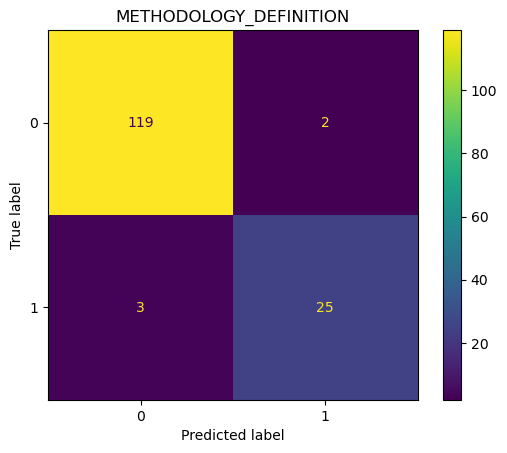

Category: MGMT_COMPENSATION_GOVERNANCE
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       117
           1       0.76      0.81      0.79        32

    accuracy                           0.91       149
   macro avg       0.86      0.87      0.86       149
weighted avg       0.91      0.91      0.91       149



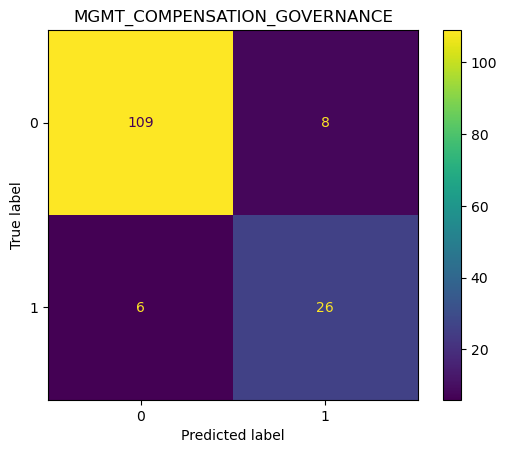

Category: NPS_SERVICE_PROVIDER
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       141
           1       0.89      1.00      0.94         8

    accuracy                           0.99       149
   macro avg       0.94      1.00      0.97       149
weighted avg       0.99      0.99      0.99       149



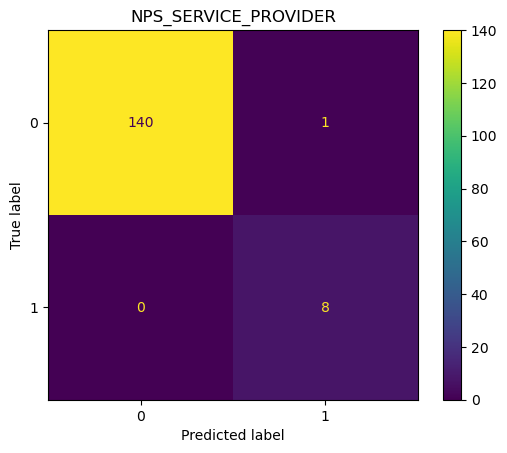

Category: OTHER
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       145
           1       1.00      1.00      1.00         4

    accuracy                           1.00       149
   macro avg       1.00      1.00      1.00       149
weighted avg       1.00      1.00      1.00       149



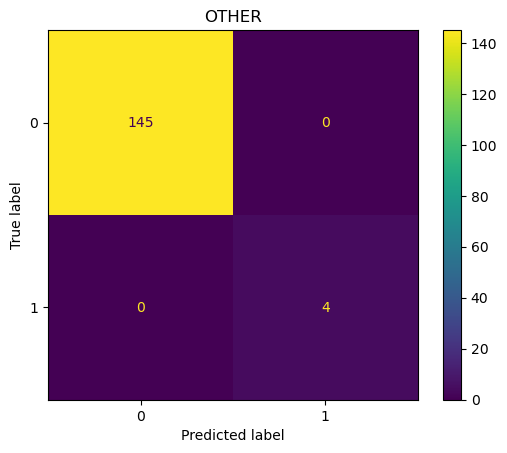

Category: QUALITATIVE_ONLY
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       145
           1       0.40      1.00      0.57         4

    accuracy                           0.96       149
   macro avg       0.70      0.98      0.78       149
weighted avg       0.98      0.96      0.97       149



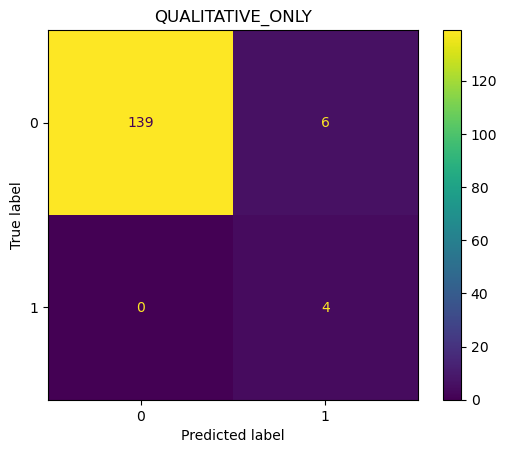

Category: TARGET_OUTLOOK
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       142
           1       1.00      0.86      0.92         7

    accuracy                           0.99       149
   macro avg       1.00      0.93      0.96       149
weighted avg       0.99      0.99      0.99       149



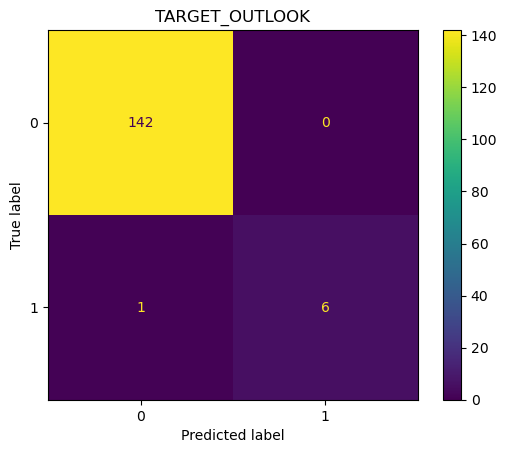

In [33]:
model = SentenceTransformer(r'C:\Users\silas\VSProjects\NPS-Crawling\src\nps_crawling\classification\model\cache\bge-m3')
for file in os.listdir(r"labeled_data\preprocessed\nps_category"):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(r"labeled_data\preprocessed\nps_category", file))
        category_name = file.split(".")[0]
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
        # Encode the text data
        train_embeddings = model.encode(train_df["text"].tolist())
        test_embeddings = model.encode(test_df["text"].tolist())
        # Train an SVM classifier
        clf = make_pipeline(StandardScaler(), SVC(kernel='linear', random_state=42))
        clf.fit(train_embeddings, train_df["label"])
        # Predict and evaluate
        test_predictions = clf.predict(test_embeddings)
        # Make a confusion matrix and classification report
        print(f"Category: {category_name}")
        print(classification_report(test_df["label"], test_predictions))
        cm = confusion_matrix(test_df["label"], test_predictions)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.title(f"{category_name}")
        plt.show()
        # Save the model
        joblib.dump(clf, rf"models\{category_name}_svm_model.joblib")

In [12]:
# Make split for nps-scores
final_data = pd.read_csv(r"labeled_data\preprocessed\final_data.csv")
nps_data = final_data[["has_numeric_nps", "snippet_text_short", "nps_value_fix", "nps_value_over", "nps_value_below"]]
nps_data = nps_data.rename(columns={"has_numeric_nps": "label", "snippet_text_short": "text"})
label_encoder = LabelEncoder()
nps_data['label'] = label_encoder.fit_transform(nps_data['label'])
nps_data.to_csv(rf"labeled_data\preprocessed\numeric_nps\has_numeric.csv", index=False)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Has Numeric NPS
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        95
           1       0.93      0.80      0.86        54

    accuracy                           0.91       149
   macro avg       0.91      0.88      0.89       149
weighted avg       0.91      0.91      0.90       149



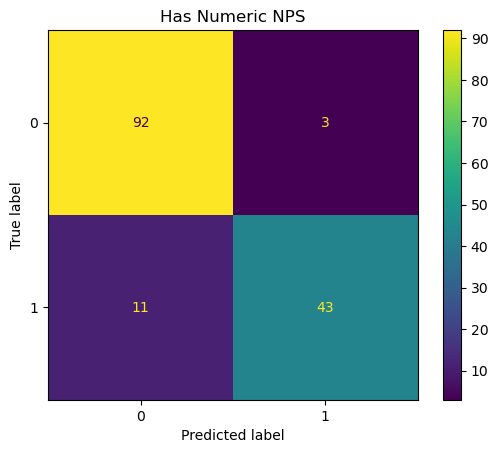

['models\\has_numeric_nps_svm_model.joblib']

In [13]:
model = SentenceTransformer(r'C:\Users\silas\VSProjects\NPS-Crawling\src\nps_crawling\classification\model\cache\bge-m3')
df = pd.read_csv(rf"labeled_data\preprocessed\numeric_nps\has_numeric.csv")
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# Encode the text data
train_embeddings = model.encode(train_df["text"].tolist())
test_embeddings = model.encode(test_df["text"].tolist())
# Train an SVM classifier
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', random_state=42))
clf.fit(train_embeddings, train_df["label"])
# Predict and evaluate
test_predictions = clf.predict(test_embeddings)
# Make a confusion matrix and classification report
print(f"Has Numeric NPS")
print(classification_report(test_df["label"], test_predictions))
cm = confusion_matrix(test_df["label"], test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Has Numeric NPS")
plt.show()
# Save the model
joblib.dump(clf, rf"models\has_numeric_nps_svm_model.joblib")

In [14]:
results_df = test_df.copy()
results_df["predictions"] = test_predictions
# only keep the rows where the prediction is 1 (has numeric nps)
results_df = results_df[results_df["predictions"] == 1]
results_df.to_csv(r"labeled_data\preprocessed\numeric_nps\predictions.csv", index=False)

In [15]:
from transformers import pipeline

pred_df = pd.read_csv(r"labeled_data\preprocessed\numeric_nps\predictions.csv")
qa_model = pipeline("question-answering", "timpal0l/mdeberta-v3-base-squad2")
pred_df["answer"] = ""
for index, row in pred_df.iterrows():
    question = "What number is the Net Promoter Score?"
    context = row["text"]  # Assuming the text column contains the context
    result = qa_model(question = question, context = context)
    pred_df.at[index, "answer"] = result['answer']

pred_df.to_csv(r"labeled_data\preprocessed\numeric_nps\predictions_with_answers.csv", index=False)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

DebertaV2ForQuestionAnswering LOAD REPORT from: timpal0l/mdeberta-v3-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
# Convert csv back to xlsx
pred_df = pd.read_csv(r"labeled_data\preprocessed\numeric_nps\predictions_with_answers.csv")
pred_df.to_excel(r"labeled_data\preprocessed\numeric_nps\predictions_with_answers.xlsx", index=False, engine="openpyxl")